In [29]:
# 2.3.1. Импорты, seed и среда
import os
import random
import numpy as np
import torch

# Data & Visualization
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Hugging Face
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

# Фиксация seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Определение устройства
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [30]:
dataset = load_dataset("tweet_eval", "emotion")

# Показать структуру
print(dataset)

# Размеры сплитов
print(f"\nTrain size: {len(dataset['train'])}")
print(f"Validation size: {len(dataset['validation'])}")
print(f"Test size: {len(dataset['test'])}")

# Названия классов (label mapping)
label_names = dataset["train"].features["label"].names
print(f"\nClasses ({len(label_names)}): {label_names}")
print("Label mapping: 0: anger, 1: joy, 2: optimism, 3: sadness")

# Несколько примеров текстов и меток
for i in range(5):
    example = dataset["train"][i]
    text = example["text"]
    label = example["label"]
    label_name = label_names[label]
    print(f"Example {i+1}:")
    print(f"Text: {text[:150]}..." if len(text) > 150 else f"Text: {text}")
    print(f"Label: {label} -> {label_name}")

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3257
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1421
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 374
    })
})

Train size: 3257
Validation size: 374
Test size: 1421

Classes (4): ['anger', 'joy', 'optimism', 'sadness']
Label mapping: 0: anger, 1: joy, 2: optimism, 3: sadness
Example 1:
Text: “Worry is a down payment on a problem you may never have'.  Joyce Meyer.  #motivation #leadership #worry
Label: 2 -> optimism
Example 2:
Text: My roommate: it's okay that we can't spell because we have autocorrect. #terrible #firstworldprobs
Label: 0 -> anger
Example 3:
Text: No but that's so cute. Atsu was probably shy about photos before but cherry helped her out uwu
Label: 1 -> joy
Example 4:
Text: Rooneys fucking untouchable isn't he? Been fucking dreadful again, depay has looked decent(ish)tonight
Label: 0 -> anger
Example

In [31]:
# 2.3.3. Токенизация
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# Выбираем несколько текстов для демонстрации
sample_texts = [
    "I am feeling very happy today!",
    "This is so sad, I want to cry.",
    "I'm surprised by the results of the match."
]

for text in sample_texts:
    print(f"\nOriginal: {text}")

    # 1. Просто токены (слова/суб-слова)
    tokens = tokenizer.tokenize(text)
    print(f"Tokens: {tokens}")

    # 2. Преобразование в ID
    encoding = tokenizer(text, return_tensors="pt")
    print(f"Input IDs: {encoding['input_ids'][0].tolist()}")
    print(f"Attention Mask: {encoding['attention_mask'][0].tolist()}")

    # 3. Special tokens
    decoded = tokenizer.decode(encoding['input_ids'][0])
    print(f"Decoded (with special tokens): {decoded}")

    # 4. Padding & Truncation demo
    padded_batch = tokenizer(sample_texts, padding=True, truncation=True, max_length=15, return_tensors="pt")
    print(f"\nBatch padding demo - Shape: {padded_batch['input_ids'].shape}")
    print(f"First sequence IDs: {padded_batch['input_ids'][0].tolist()}")
    print(f"First attention mask: {padded_batch['attention_mask'][0].tolist()}")


Original: I am feeling very happy today!
Tokens: ['i', 'am', 'feeling', 'very', 'happy', 'today', '!']
Input IDs: [101, 1045, 2572, 3110, 2200, 3407, 2651, 999, 102]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1]
Decoded (with special tokens): [CLS] i am feeling very happy today! [SEP]

Batch padding demo - Shape: torch.Size([3, 13])
First sequence IDs: [101, 1045, 2572, 3110, 2200, 3407, 2651, 999, 102, 0, 0, 0, 0]
First attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]

Original: This is so sad, I want to cry.
Tokens: ['this', 'is', 'so', 'sad', ',', 'i', 'want', 'to', 'cry', '.']
Input IDs: [101, 2023, 2003, 2061, 6517, 1010, 1045, 2215, 2000, 5390, 1012, 102]
Attention Mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Decoded (with special tokens): [CLS] this is so sad, i want to cry. [SEP]

Batch padding demo - Shape: torch.Size([3, 13])
First sequence IDs: [101, 1045, 2572, 3110, 2200, 3407, 2651, 999, 102, 0, 0, 0, 0]
First attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0]

O

In [32]:
# 2.3.4. Инференс готовой модели (Zero-shot/Zagruzka)
from transformers import pipeline

# Используем pipeline для sentiment analysis (хоть это и emotion, посмотрим как справится обычная модель)
# Выберем модель, обученную на похожей задаче (например, sentiment или emotion)
classifier = pipeline("text-classification", model="bhadresh-savani/bert-base-uncased-emotion", device=0 if torch.cuda.is_available() else -1)

test_texts = [
    "I just got promoted at work! I am so happy.",
    "My best friend moved to another country. I miss her terribly.",
    "I can't believe he did that! This is outrageous.",
    "The movie was okay, nothing special.",
    "I am scared of the dark."
]

print("===== Inference with Pretrained Emotion Model =====")
for text in test_texts:
    result = classifier(text)
    print(f"\nText: {text}")
    print(f"Prediction: {result[0]['label']} (confidence: {result[0]['score']:.3f})")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bhadresh-savani/bert-base-uncased-emotion
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


===== Inference with Pretrained Emotion Model =====

Text: I just got promoted at work! I am so happy.
Prediction: joy (confidence: 0.998)

Text: My best friend moved to another country. I miss her terribly.
Prediction: sadness (confidence: 0.989)

Text: I can't believe he did that! This is outrageous.
Prediction: anger (confidence: 0.900)

Text: The movie was okay, nothing special.
Prediction: joy (confidence: 0.997)

Text: I am scared of the dark.
Prediction: fear (confidence: 0.996)


In [33]:
# 2.3.5. Fine-tuning для классификации текста

# 1. Токенизация датасета
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, max_length=128)

# Применяем токенизацию ко всем сплитам
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# 2. Подготовка данных для Trainer
# Убираем текстовый столбец, так как он больше не нужен, и переименовываем label -> labels
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

# 3. Загрузка модели для классификации
num_labels = len(label_names)
model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=num_labels)
model.to(device)

# 4. Data collator для динамического паддинга (эффективнее)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 5. Аргументы обучения
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    logging_dir="./logs",
    logging_steps=100,
    seed=42,
    report_to="none",
)

# 6. Функция для метрик
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {
        "accuracy": acc,
        "f1_macro": f1
    }

# 7. Инициализация Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

# 9. Оценка лучшей модели на тесте
test_results = trainer.evaluate(tokenized_datasets["test"])
print(f"Test Results: {test_results}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.695323,0.607724,0.788770,0.694143
2,0.468515,0.575563,0.802139,0.731670
3,0.267228,0.602563,0.804813,0.730120


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Test Results: {'eval_loss': 0.5433497428894043, 'eval_accuracy': 0.8078817733990148, 'eval_f1_macro': 0.7628105374188102, 'eval_runtime': 4.0085, 'eval_samples_per_second': 354.497, 'eval_steps_per_second': 22.203, 'epoch': 3.0}


Accuracy: 0.8079
F1 Macro: 0.7628


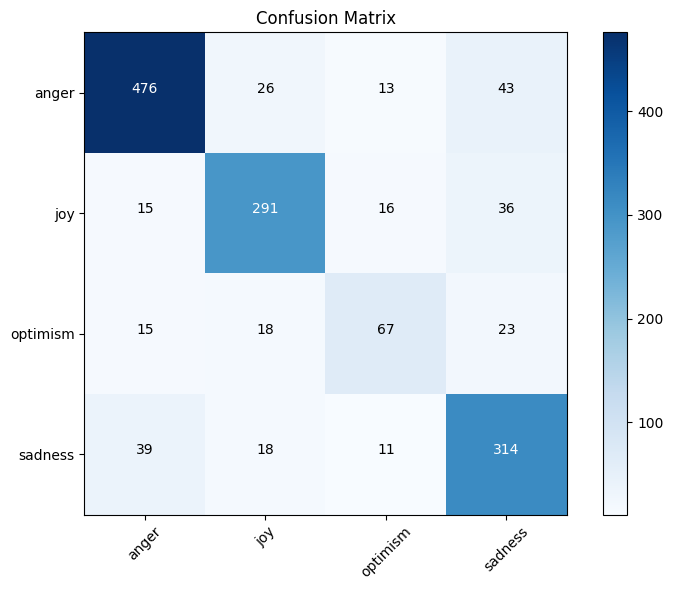

              precision    recall  f1-score   support

       anger       0.87      0.85      0.86       558
         joy       0.82      0.81      0.82       358
    optimism       0.63      0.54      0.58       123
     sadness       0.75      0.82      0.79       382

    accuracy                           0.81      1421
   macro avg       0.77      0.76      0.76      1421
weighted avg       0.81      0.81      0.81      1421


Example 1:
Text: #Deppression is real. Partners w/ #depressed people truly dont understand the depth in which they af...
True: sadness | Predicted: sadness

Example 2:
Text: @user Interesting choice of words... Are you confirming that governments fund #terrorism? Bit of an ...
True: anger | Predicted: anger

Example 3:
Text: My visit to hospital for care triggered #trauma from accident 20+yrs ago and image of my dead brothe...
True: sadness | Predicted: sadness

Example 4:
Text: @user Welcome to #MPSVT! We are delighted to have you! #grateful #MPSVT #relatio

In [34]:
# 2.3.6. Оценка качества и краткий анализ ошибок

# Получаем предсказания для тестовой выборки
test_data = tokenized_datasets["test"]
predictions_output = trainer.predict(tokenized_datasets["test"])
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

# 1. Accuracy и F1 Macro
test_accuracy = accuracy_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Accuracy: {test_accuracy:.4f}")
print(f"F1 Macro: {test_f1:.4f}")

# 2. Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, label_names, rotation=45)
plt.yticks(tick_marks, label_names)

# Добавляем значения в ячейки
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()

cm_path = "artifacts/confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()

# 3. Подробный отчет по каждому классу
print(classification_report(y_true, y_pred, target_names=label_names))

# 4. Показ 10 примеров предсказаний
test_dataset_original = dataset["test"]
for i in range(10):
    text = test_dataset_original[i]["text"]
    true_label = test_dataset_original[i]["label"]
    pred_label = y_pred[i]

    print(f"\nExample {i+1}:")
    print(f"Text: {text[:100]}..." if len(text) > 100 else f"Text: {text}")
    print(f"True: {label_names[true_label]} | Predicted: {label_names[pred_label]}")
    if true_label != pred_label:
        print(">>> MISCLASSIFICATION <<<")

# 5. Комментарий по ошибкам
errors_idx = np.where(y_true != y_pred)[0]
print(f"Total misclassifications: {len(errors_idx)} out of {len(y_true)} ({len(errors_idx)/len(y_true)*100:.2f}%)")

# Покажем 3 примера ошибок с комментариями
for idx in errors_idx[:3]:
    idx = int(idx)
    text = test_dataset_original[idx]["text"]
    true_l = label_names[y_true[idx]]
    pred_l = label_names[y_pred[idx]]
    print(f"\nText: \"{text}\"")
    print(f"True: {true_l} -> Predicted: {pred_l}")



## Краткий комментарий ошибок

### 1. `#cmbyn` tweet: sadness → joy
**Причина**: Неоднозначность текста. Отсутствует контекст и явные маркеры эмоций.

### 2. `"Pressured. 😦"`: sadness → anger
**Причина**: Эмодзи 😦 (разочарование/печаль) и слово "pressured" (давление) создают негативный контекст. Модель путает внешнее проявление давления с гневом (anger), хотя эмоция ближе к sadness/тревоге.

### 3. `#bipolar`: anger → sadness
**Причина**: Текст выражает фрустрацию по поводу советов "mind over matter" для лечения биполярного расстройства. Хотя автор явно негодует (anger), модель интерпретирует упоминание болезни как sadness.

## Общая закономерность ошибок
- **Короткие/неоднозначные тексты** (примеры 1-2)
- **Пересекающиеся эмоциональные состояния** (гнев ↔ печаль, радость ↔ оптимизм)
- **Отсутствие явных маркеров эмоций** в тексте

In [35]:
import os
import pandas as pd
from datetime import datetime

predictions_output = trainer.predict(tokenized_datasets["test"])
y_pred_probs = predictions_output.predictions
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = predictions_output.label_ids

# Получаем confidence (вероятность предсказанного класса)
confidences = np.max(y_pred_probs, axis=1)

# Загружаем оригинальные тексты
test_texts_original = dataset["test"]["text"]

# Берем все примеры или семплируем? Лучше все для полноты
sample_df = pd.DataFrame({
    'text': test_texts_original,
    'true_label': [label_names[l] for l in y_true],
    'pred_label': [label_names[l] for l in y_pred],
    'confidence': confidences
})

# Сохраняем в CSV
csv_path = "artifacts/sample_predictions.csv"
sample_df.to_csv(csv_path, index=False)

# Показываем первые 10 строк для проверки
print(sample_df.head(5))

                                                text true_label pred_label  \
0  #Deppression is real. Partners w/ #depressed p...    sadness    sadness   
1  @user Interesting choice of words... Are you c...      anger      anger   
2  My visit to hospital for care triggered #traum...    sadness    sadness   
3  @user Welcome to #MPSVT! We are delighted to h...        joy        joy   
4                       What makes you feel #joyful?        joy        joy   

   confidence  
0    2.916401  
1    1.000556  
2    3.295587  
3    2.983793  
4    2.839497  
